In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.utils import PolicyEDA, FeatureEngineering, DataCleaningUtils
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


/home/tony-ubuntu/anaconda3/envs/cpa_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = PolicyEDA()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# import IEA scored data
policy_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_scored_cpsi.csv"))
policy_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752


In [6]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9255 entries, 0 to 9254
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        9255 non-null   object 
 1   year               9255 non-null   int64  
 2   avg_policy_score   9255 non-null   float64
 3   policy_count       9255 non-null   int64  
 4   dominant_topic     9255 non-null   object 
 5   dominant_category  9255 non-null   object 
 6   log_policy_count   9255 non-null   float64
 7   CPSI               9255 non-null   float64
 8   CPSI_power_3       9255 non-null   float64
 9   CPSI_geom_4        9255 non-null   float64
 10  CPSI_geom_7        9255 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 795.5+ KB


In [7]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [8]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [9]:
# Load the wb controls
wb_controls_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_control_vars.csv"))
wb_controls_df.head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
0,2022,1.040350e+12,731821393.0,565.488909,NaN,7.303970,37.909012,26.921919,29.737205,NaN
1,2021,1.004646e+12,713090928.0,570.998888,NaN,7.156658,37.393633,26.075267,29.955194,NaN
2,2020,9.606813e+11,694446100.0,563.976201,66.123449,7.107927,36.884034,25.434235,30.174252,NaN
3,2019,9.890095e+11,675950189.0,586.441491,63.387090,7.212707,36.384272,26.421751,30.391626,NaN
4,2018,9.677734e+11,657801085.0,583.763039,62.242631,7.273489,35.893398,27.859732,30.611512,NaN


In [10]:
wb_controls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               6118 non-null   int64  
 1   gdp_2015_usd       5832 non-null   float64
 2   population         6095 non-null   float64
 3   energy_per_capita  4565 non-null   float64
 4   renewable_share    5710 non-null   float64
 5   energy_intensity   4404 non-null   float64
 6   urbanization_rate  6049 non-null   float64
 7   industry_size      5551 non-null   float64
 8   forest_area        5953 non-null   float64
 9   iso_alpha_3        4945 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 478.1+ KB


In [11]:
global_policy_emissions_df = pd.merge(policy_df, emissions_df, on=["iso_alpha_3", "year"], how="inner")
global_policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,total_emissions
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,25.390391
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,23.723115
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,26.383509
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,27.071538
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,27.128799


In [12]:
# Now let's merge the wb controls data
global_policy_emissions_df = pd.merge(global_policy_emissions_df, wb_controls_df, on=["iso_alpha_3", "year"], how="inner")
global_policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,region,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,25.390391,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,23.723115,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,26.383509,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,27.071538,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,27.128799,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782


In [13]:
## remove unnecessary columns
global_policy_emissions_df = global_policy_emissions_df.drop(columns=["avg_policy_score", 
                                                        "policy_count", 
                                                        "dominant_topic",
                                                        "dominant_category",
                                                        "log_policy_count"
                    ])

# move total_emissions to the end
global_policy_emissions_df = global_policy_emissions_df[[col for col in global_policy_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
global_policy_emissions_df.head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [14]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        4165 non-null   object 
 1   year               4165 non-null   int64  
 2   CPSI               4165 non-null   float64
 3   CPSI_power_3       4165 non-null   float64
 4   CPSI_geom_4        4165 non-null   float64
 5   CPSI_geom_7        4165 non-null   float64
 6   income_group       4165 non-null   object 
 7   region             4165 non-null   object 
 8   gdp_2015_usd       4092 non-null   float64
 9   population         4165 non-null   float64
 10  energy_per_capita  3353 non-null   float64
 11  renewable_share    4028 non-null   float64
 12  energy_intensity   3257 non-null   float64
 13  urbanization_rate  4165 non-null   float64
 14  industry_size      3994 non-null   float64
 15  forest_area        4126 non-null   float64
 16  total_emissions    4165 

## Data Cleaning

In [15]:
feats_to_drop = ["CPSI", "CPSI_power_3", "CPSI_geom_4"]
global_policy_emissions_df = global_policy_emissions_df.drop(columns=feats_to_drop)

# Rename index to CPSI
global_policy_emissions_df = global_policy_emissions_df.rename(columns={"CPSI_geom_7": "policy_stringency_index"})
global_policy_emissions_df.head()

,iso_alpha_3,year,policy_stringency_index,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,1.643752,Low income,South Asia,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,1.643752,Low income,South Asia,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,1.643752,Low income,South Asia,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,1.643752,Low income,South Asia,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,1.643752,Low income,South Asia,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [16]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   iso_alpha_3              4165 non-null   object 
 1   year                     4165 non-null   int64  
 2   policy_stringency_index  4165 non-null   float64
 3   income_group             4165 non-null   object 
 4   region                   4165 non-null   object 
 5   gdp_2015_usd             4092 non-null   float64
 6   population               4165 non-null   float64
 7   energy_per_capita        3353 non-null   float64
 8   renewable_share          4028 non-null   float64
 9   energy_intensity         3257 non-null   float64
 10  urbanization_rate        4165 non-null   float64
 11  industry_size            3994 non-null   float64
 12  forest_area              4126 non-null   float64
 13  total_emissions          4165 non-null   float64
dtypes: float64(10), int64(1)

In [17]:
# Get the subset df where gdp_2015_usd is null
gdp_null_df = global_policy_emissions_df[global_policy_emissions_df["gdp_2015_usd"].isnull()]
gdp_null_df.iso_alpha_3.unique()

array(['DJI', 'ERI', 'FRO', 'GRL', 'NCL', 'PRK', 'YEM'], dtype=object)

In [18]:
global_policy_emissions_df = global_policy_emissions_df.dropna(subset=["gdp_2015_usd"])

In [19]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = global_policy_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 31
    iso_alpha_3  count
157         ALB     21
158         BIH     20
159         BGR     20
160         WSM     20
161         HKG     20
162         GNQ     20
163         TON     20
164         CYP     20
165         YEM     19
166         SVK     19
167         VCT     18
168         GRD     18
169         BHS     18
170         ATG     18
171         DMA     18
172         KNA     18
173         JAM     18
174         LCA     18
175         MDV     17
176         BRN     17
177         SYC     16
178         GRL     15
179         FRO     15
180         ERI     12
181         DJI     10
182         CYM      9
183         BMU      9
184         PYF      9
185         MAC      6
186         PLW      2
187         NCL      1


In [20]:
# Remove the countries with less than x records from the global_policy_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)

In [21]:
# Check the max year for every country
max_year_df = global_policy_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2022]


In [22]:
# countries_with_max_year_less_than_2015 = max_year_df[max_year_df["max_year"] < 2015]
# print(f"Countries with max year less than 2015: {countries_with_max_year_less_than_2015.shape[0]}")
# print(countries_with_max_year_less_than_2015)
# # Remove the countries with max year less than 2015 from the global_policy_emissions_df
# countries_to_remove = countries_with_max_year_less_than_2015["iso_alpha_3"].tolist()
# global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
# global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)

In [23]:
# def check_discontinuous_years(df):
#     discontinuous_years = []
#     for iso_alpha_3 in df["iso_alpha_3"].unique():
#         country_df = df[df["iso_alpha_3"] == iso_alpha_3]
#         years = sorted(country_df["year"].tolist())
#         years_range = list(range(min(years), max(years) + 1))
#         if years != years_range:
#             print(f"Discontinuous years for {iso_alpha_3}: {years_range} vs {years}")
#             discontinuous_years.append(iso_alpha_3)
#     return discontinuous_years

# discontinuous_years = check_discontinuous_years(global_policy_emissions_df)
# print(f"Countries with discontinuous years: {len(discontinuous_years)}")
# print(discontinuous_years)

In [24]:
# Check for duplicates
duplicates_df = global_policy_emissions_df[global_policy_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, policy_stringency_index, income_group, region, gdp_2015_usd, population, energy_per_capita, renewable_share, energy_intensity, urbanization_rate, industry_size, forest_area, total_emissions]
Index: []


In [25]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3611 entries, 0 to 3610
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   iso_alpha_3              3611 non-null   object 
 1   year                     3611 non-null   int64  
 2   policy_stringency_index  3611 non-null   float64
 3   income_group             3611 non-null   object 
 4   region                   3611 non-null   object 
 5   gdp_2015_usd             3611 non-null   float64
 6   population               3611 non-null   float64
 7   energy_per_capita        3073 non-null   float64
 8   renewable_share          3485 non-null   float64
 9   energy_intensity         3050 non-null   float64
 10  urbanization_rate        3611 non-null   float64
 11  industry_size            3505 non-null   float64
 12  forest_area              3598 non-null   float64
 13  total_emissions          3611 non-null   float64
dtypes: float64(10), int64(1)

In [26]:
global_policy_emissions_df = global_policy_emissions_df.drop(columns=["energy_intensity", "energy_per_capita"])

In [27]:
# Fill missing values for numeric columns
global_policy_emissions_df = dcu.fill_numeric_missing_by_group(global_policy_emissions_df, ["iso_alpha_3"])

In [28]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3611 entries, 0 to 3610
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   iso_alpha_3              3611 non-null   object 
 1   year                     3611 non-null   int64  
 2   policy_stringency_index  3611 non-null   float64
 3   income_group             3611 non-null   object 
 4   region                   3611 non-null   object 
 5   gdp_2015_usd             3611 non-null   float64
 6   population               3611 non-null   float64
 7   renewable_share          3611 non-null   float64
 8   urbanization_rate        3611 non-null   float64
 9   industry_size            3611 non-null   float64
 10  forest_area              3611 non-null   float64
 11  total_emissions          3611 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 366.7+ KB


In [29]:
# Check how many countries we have left:
global_policy_emissions_df.iso_alpha_3.unique().shape

(157,)

## EDA 1

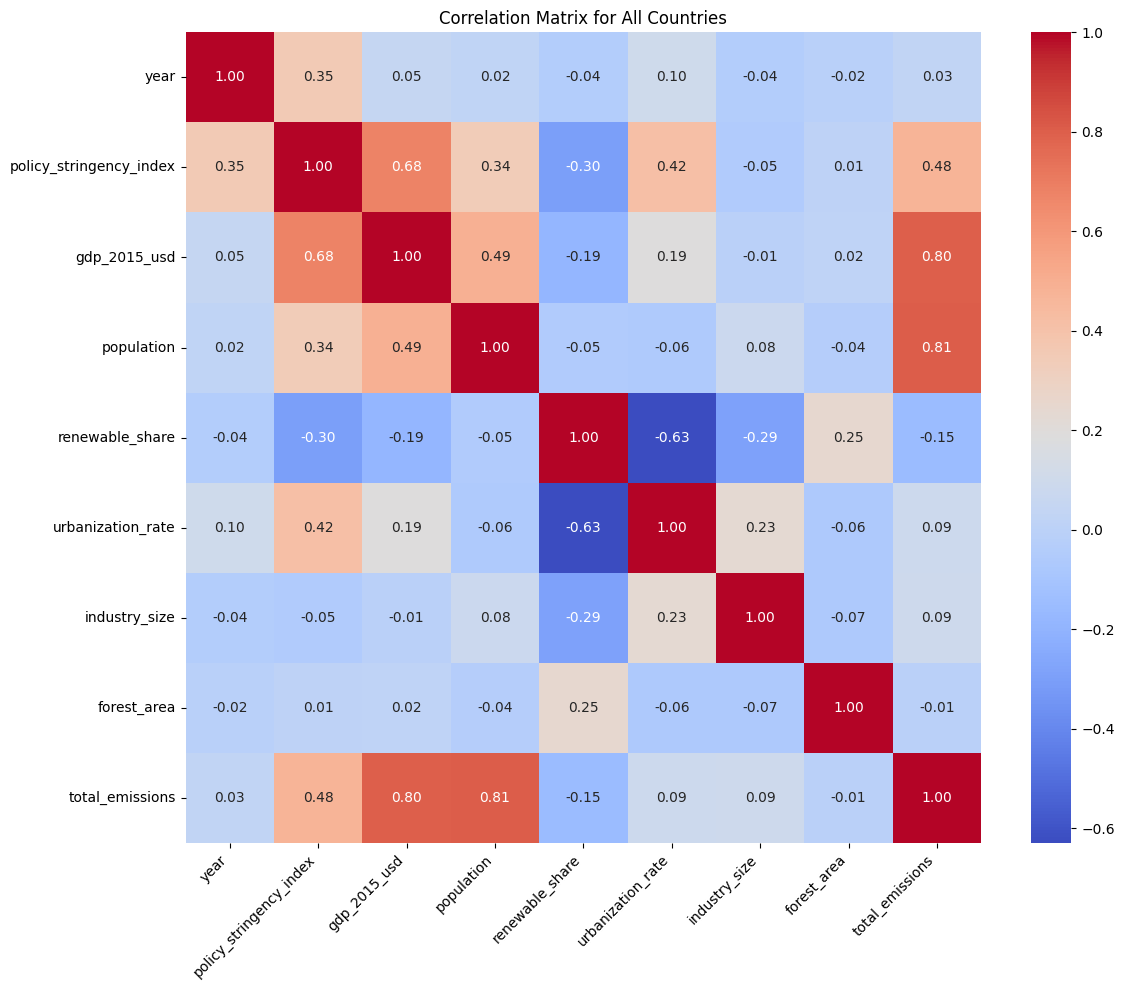

In [30]:
eda_utils.plot_correlation_matrix(global_policy_emissions_df)

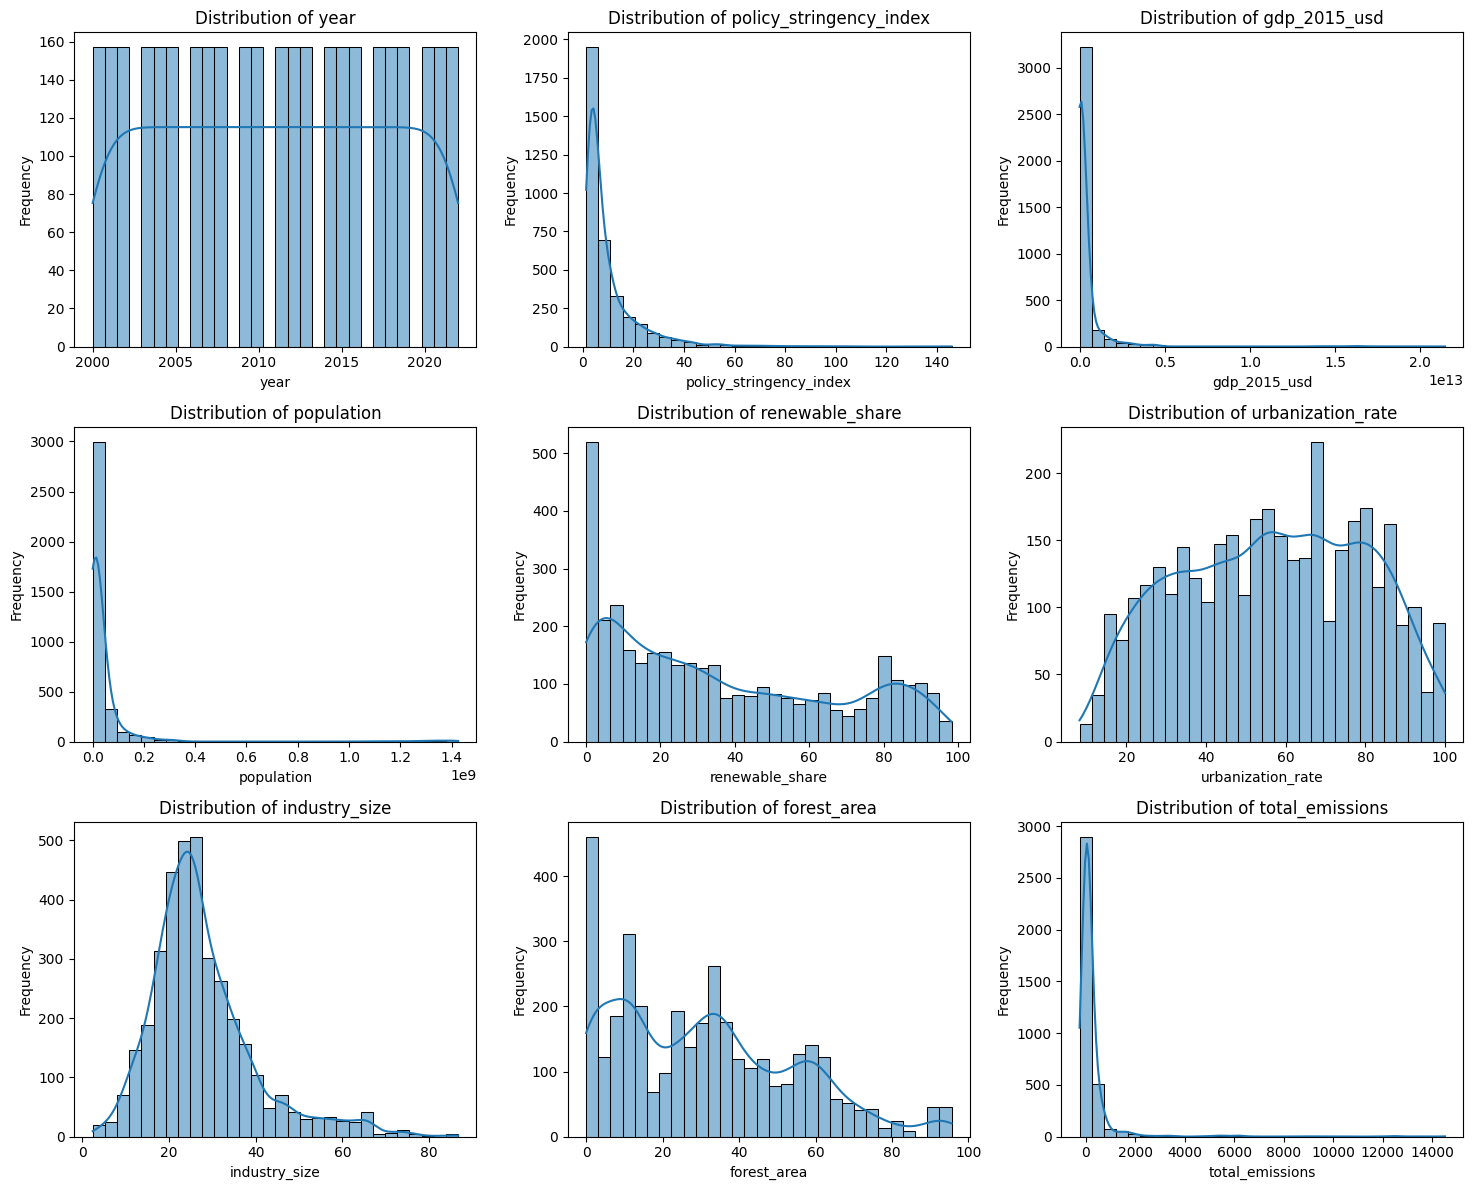

In [31]:
eda_utils.plot_numeric_fields_distributions(global_policy_emissions_df)

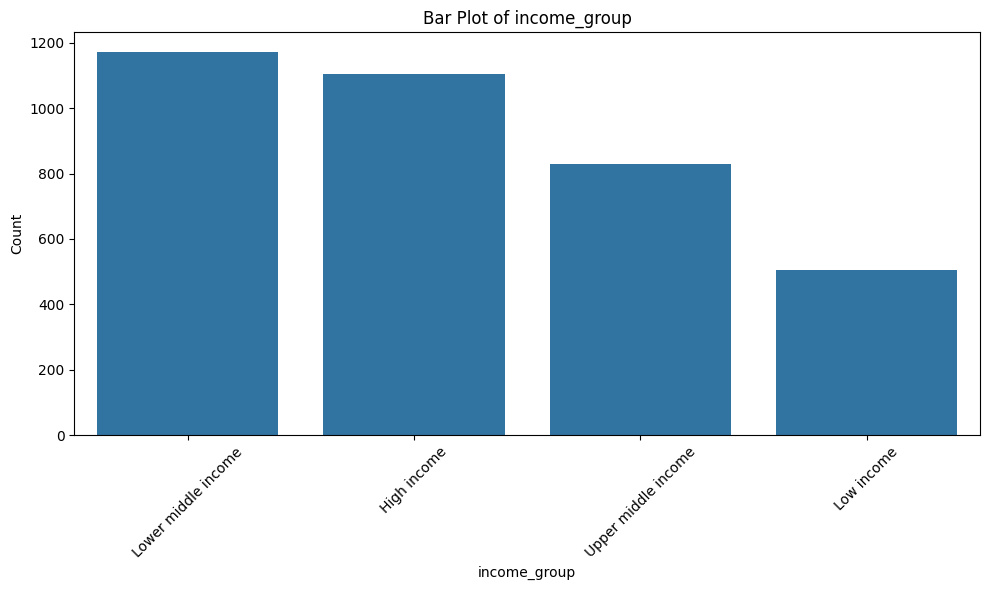

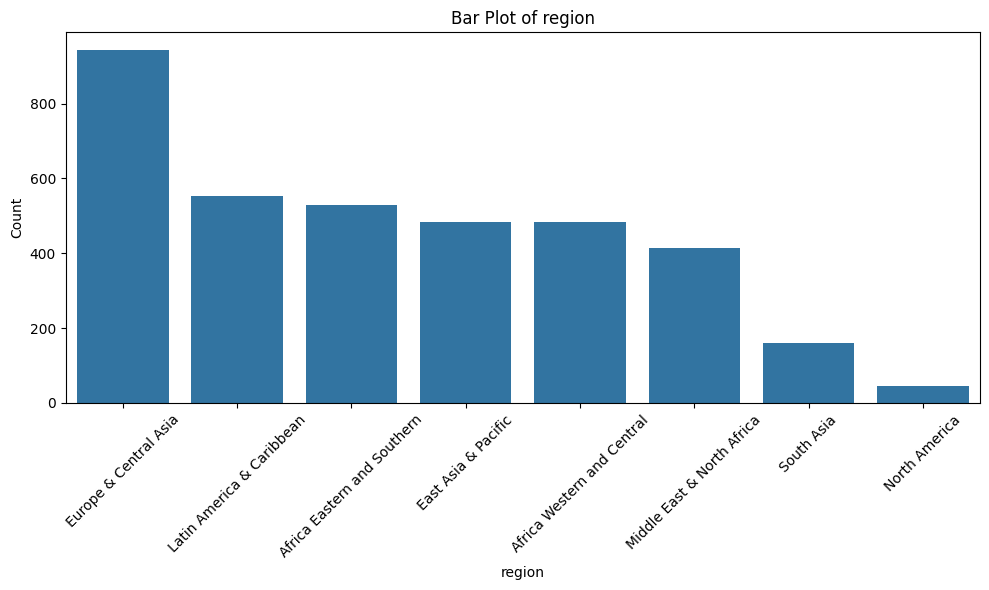

In [32]:
eda_utils.plot_barplot_for_categorical_field(global_policy_emissions_df, "income_group")
eda_utils.plot_barplot_for_categorical_field(global_policy_emissions_df, "region")

## Feature Engineering for Numeric Features

In [33]:
# Drop gdp
global_policy_emissions_df = global_policy_emissions_df.drop(columns=["gdp_2015_usd", "renewable_share"])

In [34]:
numeric_cols = global_policy_emissions_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year", "total_emissions"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]

training_df = fe.generate_growth_rate_features(global_policy_emissions_df, columns=numeric_cols)
training_df.head()

,iso_alpha_3,year,policy_stringency_index,income_group,region,population,urbanization_rate,industry_size,forest_area,total_emissions,policy_stringency_index_growth_rate,population_growth_rate,urbanization_rate_growth_rate,industry_size_growth_rate,forest_area_growth_rate
0,AFG,2000,1.643752,Low income,South Asia,20130327.0,22.078,16.050368,1.852782,25.390391,NaN,NaN,NaN,NaN,NaN
22,AFG,2022,3.421277,Low income,South Asia,40578842.0,26.616,16.050368,1.852782,38.457458,1.081383,1.015806,0.205544,0.000000,0.0
21,AFG,2021,3.421277,Low income,South Asia,40000412.0,26.314,14.273657,1.852782,38.293652,0.000000,-0.014254,-0.011347,-0.110696,0.0
20,AFG,2020,2.979136,Low income,South Asia,39068979.0,26.026,12.952600,1.852782,37.490896,-0.129233,-0.023286,-0.010945,-0.092552,0.0
19,AFG,2019,2.979136,Low income,South Asia,37856121.0,25.754,14.058112,1.852782,39.663300,0.000000,-0.031044,-0.010451,0.085351,0.0


In [35]:
training_df = fe.generate_lagged_features(training_df, ["total_emissions"], max_lag=1)
training_df.head()

,iso_alpha_3,year,policy_stringency_index,income_group,region,population,urbanization_rate,industry_size,forest_area,total_emissions,policy_stringency_index_growth_rate,population_growth_rate,urbanization_rate_growth_rate,industry_size_growth_rate,forest_area_growth_rate,total_emissions_lag1
0,AFG,2000,1.643752,Low income,South Asia,20130327.0,22.078,16.050368,1.852782,25.390391,NaN,NaN,NaN,NaN,NaN,NaN
22,AFG,2022,3.421277,Low income,South Asia,40578842.0,26.616,16.050368,1.852782,38.457458,1.081383,1.015806,0.205544,0.000000,0.0,25.390391
21,AFG,2021,3.421277,Low income,South Asia,40000412.0,26.314,14.273657,1.852782,38.293652,0.000000,-0.014254,-0.011347,-0.110696,0.0,38.457458
20,AFG,2020,2.979136,Low income,South Asia,39068979.0,26.026,12.952600,1.852782,37.490896,-0.129233,-0.023286,-0.010945,-0.092552,0.0,38.293652
19,AFG,2019,2.979136,Low income,South Asia,37856121.0,25.754,14.058112,1.852782,39.663300,0.000000,-0.031044,-0.010451,0.085351,0.0,37.490896


In [36]:
cols_to_keep = ["iso_alpha_3", "year", "policy_stringency_index", "income_group", "region", "population"] + [col for col in training_df.columns if "growth_rate" in col or "lag" in col] + ["total_emissions"]
training_df = training_df[cols_to_keep]
training_df.head()

,iso_alpha_3,year,policy_stringency_index,income_group,region,population,policy_stringency_index_growth_rate,population_growth_rate,urbanization_rate_growth_rate,industry_size_growth_rate,forest_area_growth_rate,total_emissions_lag1,total_emissions
0,AFG,2000,1.643752,Low income,South Asia,20130327.0,NaN,NaN,NaN,NaN,NaN,NaN,25.390391
22,AFG,2022,3.421277,Low income,South Asia,40578842.0,1.081383,1.015806,0.205544,0.000000,0.0,25.390391,38.457458
21,AFG,2021,3.421277,Low income,South Asia,40000412.0,0.000000,-0.014254,-0.011347,-0.110696,0.0,38.457458,38.293652
20,AFG,2020,2.979136,Low income,South Asia,39068979.0,-0.129233,-0.023286,-0.010945,-0.092552,0.0,38.293652,37.490896
19,AFG,2019,2.979136,Low income,South Asia,37856121.0,0.000000,-0.031044,-0.010451,0.085351,0.0,37.490896,39.663300


In [37]:
training_df = fe.log_transform_high_skew(training_df, training_df.select_dtypes(include=["float64", "int64"]).columns.tolist(), skew_threshold=0.5)
training_df.head()

Columns dropped due to high skewness: ['policy_stringency_index', 'population']


,iso_alpha_3,year,income_group,region,policy_stringency_index_growth_rate,population_growth_rate,urbanization_rate_growth_rate,industry_size_growth_rate,forest_area_growth_rate,total_emissions_lag1,total_emissions,log_policy_stringency_index,log_population
0,AFG,2000,Low income,South Asia,NaN,NaN,NaN,NaN,NaN,NaN,25.390391,0.496981,16.817738
22,AFG,2022,Low income,South Asia,1.081383,1.015806,0.205544,0.000000,0.0,25.390391,38.457458,1.230014,17.518757
21,AFG,2021,Low income,South Asia,0.000000,-0.014254,-0.011347,-0.110696,0.0,38.457458,38.293652,1.230014,17.504400
20,AFG,2020,Low income,South Asia,-0.129233,-0.023286,-0.010945,-0.092552,0.0,38.293652,37.490896,1.091633,17.480839
19,AFG,2019,Low income,South Asia,0.000000,-0.031044,-0.010451,0.085351,0.0,37.490896,39.663300,1.091633,17.449303


**TODO**: Time features

Keep “year” as a numeric.

Optionally add years_since_2000 = year - 2000 or a polynomial of “year” if you believe trends are non-linear.

## EDA 2

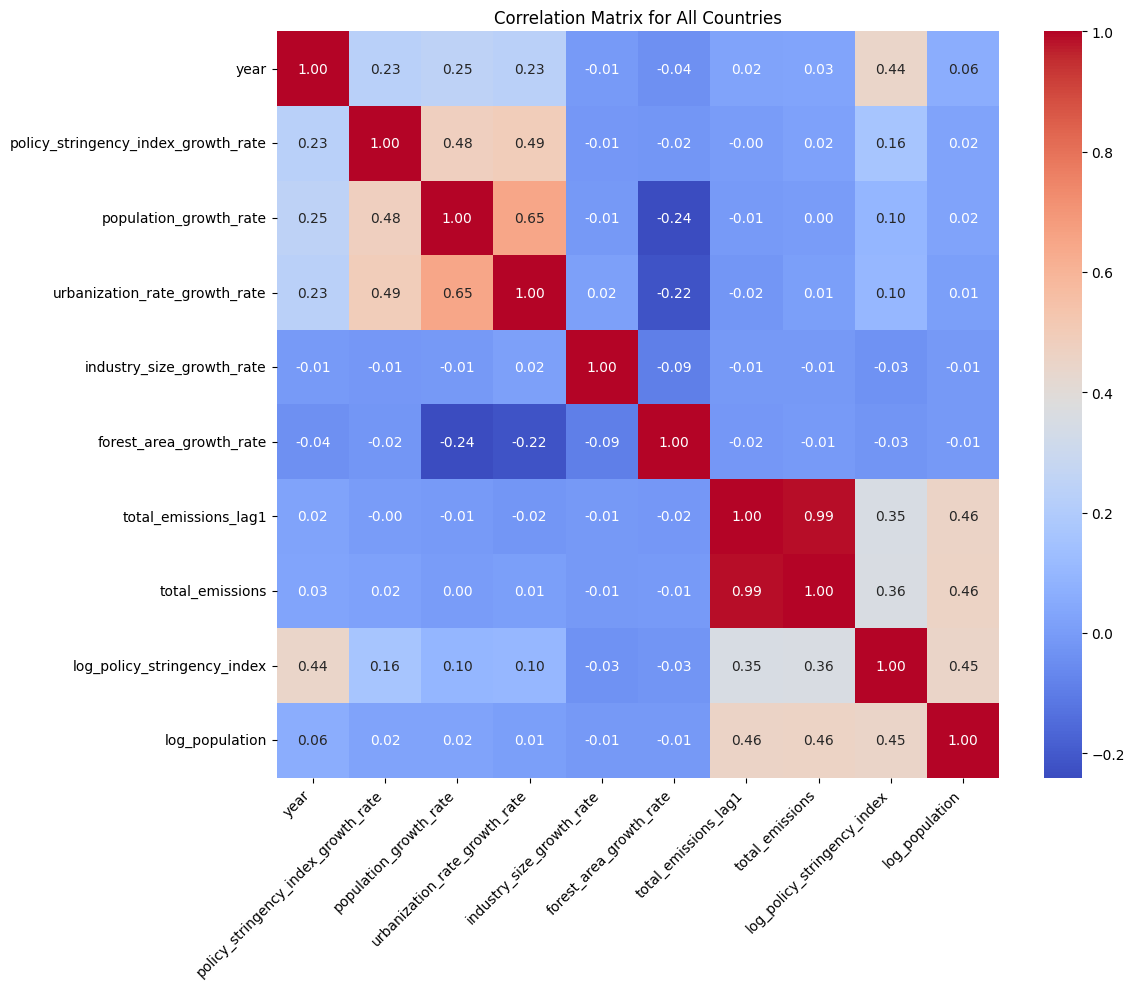

In [38]:
eda_utils.plot_correlation_matrix(training_df)

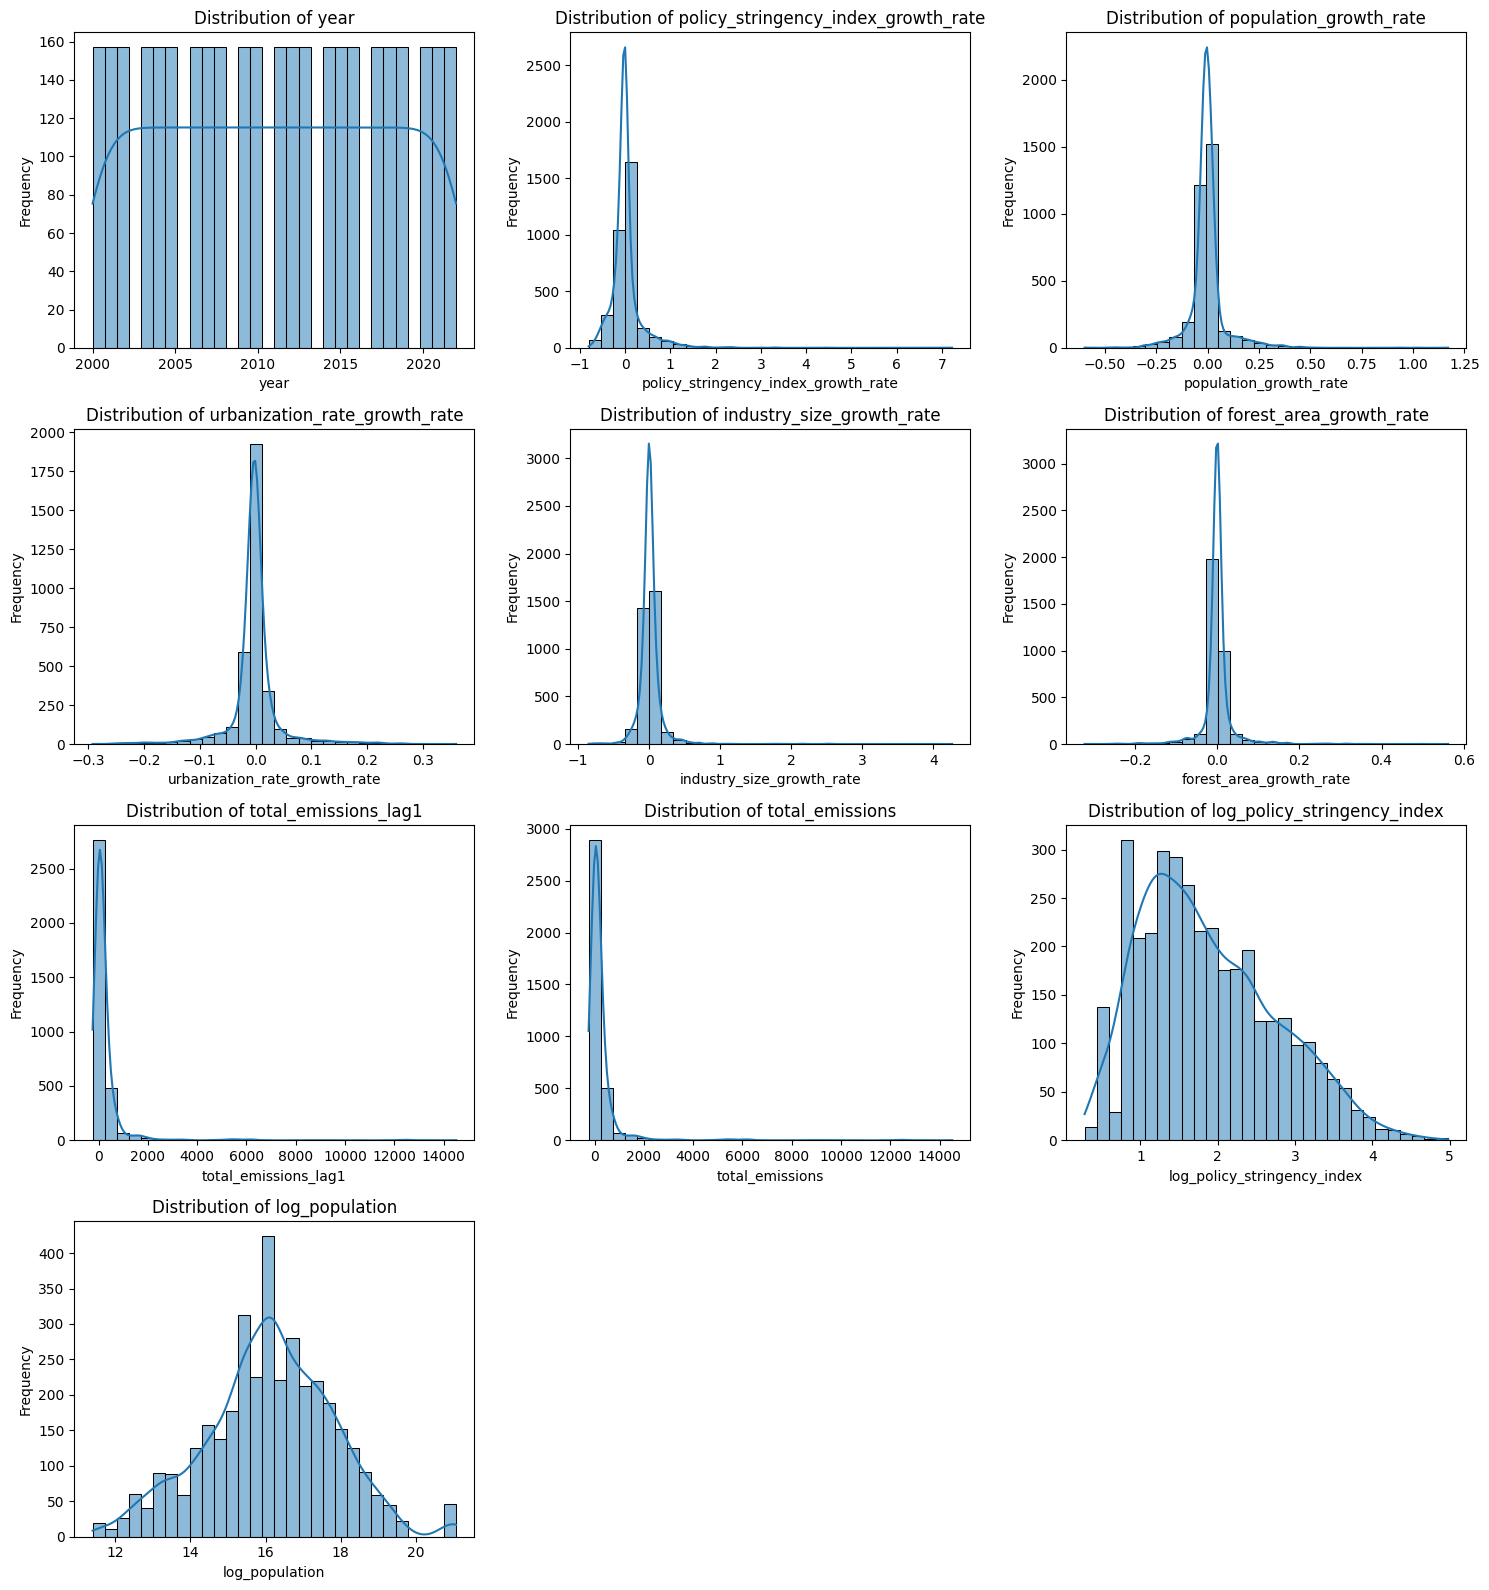

In [39]:
eda_utils.plot_numeric_fields_distributions(training_df)

## Feature Engineering Categorical Features

In [40]:
# One hot encode categorical features
categorical_cols = ["income_group", "region"]
training_df = fe.one_hot_encode_categorical(training_df, categorical_cols)
training_df.head()

,iso_alpha_3,year,policy_stringency_index_growth_rate,population_growth_rate,urbanization_rate_growth_rate,industry_size_growth_rate,forest_area_growth_rate,total_emissions_lag1,total_emissions,log_policy_stringency_index,...,income_group_Lower middle income,income_group_Upper middle income,region_Africa Eastern and Southern,region_Africa Western and Central,region_East Asia & Pacific,region_Europe & Central Asia,region_Latin America & Caribbean,region_Middle East & North Africa,region_North America,region_South Asia
0,AFG,2000,NaN,NaN,NaN,NaN,NaN,NaN,25.390391,0.496981,...,0,0,0,0,0,0,0,0,0,1
22,AFG,2022,1.081383,1.015806,0.205544,0.000000,0.0,25.390391,38.457458,1.230014,...,0,0,0,0,0,0,0,0,0,1
21,AFG,2021,0.000000,-0.014254,-0.011347,-0.110696,0.0,38.457458,38.293652,1.230014,...,0,0,0,0,0,0,0,0,0,1
20,AFG,2020,-0.129233,-0.023286,-0.010945,-0.092552,0.0,38.293652,37.490896,1.091633,...,0,0,0,0,0,0,0,0,0,1
19,AFG,2019,0.000000,-0.031044,-0.010451,0.085351,0.0,37.490896,39.663300,1.091633,...,0,0,0,0,0,0,0,0,0,1


In [41]:
training_df = training_df.dropna().reset_index(drop=True)
training_df.head()

,iso_alpha_3,year,policy_stringency_index_growth_rate,population_growth_rate,urbanization_rate_growth_rate,industry_size_growth_rate,forest_area_growth_rate,total_emissions_lag1,total_emissions,log_policy_stringency_index,...,income_group_Lower middle income,income_group_Upper middle income,region_Africa Eastern and Southern,region_Africa Western and Central,region_East Asia & Pacific,region_Europe & Central Asia,region_Latin America & Caribbean,region_Middle East & North Africa,region_North America,region_South Asia
0,AFG,2022,1.081383,1.015806,0.205544,0.000000,0.0,25.390391,38.457458,1.230014,...,0,0,0,0,0,0,0,0,0,1
1,AFG,2021,0.000000,-0.014254,-0.011347,-0.110696,0.0,38.457458,38.293652,1.230014,...,0,0,0,0,0,0,0,0,0,1
2,AFG,2020,-0.129233,-0.023286,-0.010945,-0.092552,0.0,38.293652,37.490896,1.091633,...,0,0,0,0,0,0,0,0,0,1
3,AFG,2019,0.000000,-0.031044,-0.010451,0.085351,0.0,37.490896,39.663300,1.091633,...,0,0,0,0,0,0,0,0,0,1
4,AFG,2018,-0.212939,-0.029403,-0.010057,-0.047721,0.0,39.663300,40.780451,0.852184,...,0,0,0,0,0,0,0,0,0,1


In [42]:
# training_df = training_df.drop(columns=["iso_alpha_3"])

In [43]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3432 entries, 0 to 3431
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   iso_alpha_3                          3432 non-null   object 
 1   year                                 3432 non-null   int64  
 2   policy_stringency_index_growth_rate  3432 non-null   float64
 3   population_growth_rate               3432 non-null   float64
 4   urbanization_rate_growth_rate        3432 non-null   float64
 5   industry_size_growth_rate            3432 non-null   float64
 6   forest_area_growth_rate              3432 non-null   float64
 7   total_emissions_lag1                 3432 non-null   float64
 8   total_emissions                      3432 non-null   float64
 9   log_policy_stringency_index          3432 non-null   float64
 10  log_population                       3432 non-null   float64
 11  income_group_High income      

In [46]:

# Assume `training_df` is your preprocessed DataFrame
feature_cols = [c for c in training_df.columns if c not in ['iso_alpha_3', 'year', 'total_emissions']]
X = training_df[feature_cols]
y = training_df['total_emissions']
groups = training_df['iso_alpha_3']
years = training_df['year']

# 1. Time-series train/test split (hold out last 5 years)
cutoff_year = training_df['year'].max() - 5
train_mask = training_df['year'] <= cutoff_year
test_mask = training_df['year'] > cutoff_year

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]
groups_train = groups.loc[train_mask]

Test MSE: 30705.078, R2: 0.980
Fold 1 - MSE: 18819.455, R2: 0.908
Fold 2 - MSE: 2074.304, R2: 0.950
Fold 3 - MSE: 574512.437, R2: 0.800
Fold 4 - MSE: 13560.069, R2: 0.900
Fold 5 - MSE: 175421.852, R2: 0.837
CV avg MSE: 156877.623, R2: 0.879
Time-series CV Fold 1 - MSE: 5431.276, R2: 0.900
Time-series CV Fold 2 - MSE: 426778.799, R2: -0.256
Time-series CV Fold 3 - MSE: 2128.847, R2: 0.866
Time-series CV Fold 4 - MSE: 4058.138, R2: 0.964
Time-series CV Fold 5 - MSE: 185201.509, R2: 0.853
Time-series CV avg MSE: 124719.714, R2: 0.665


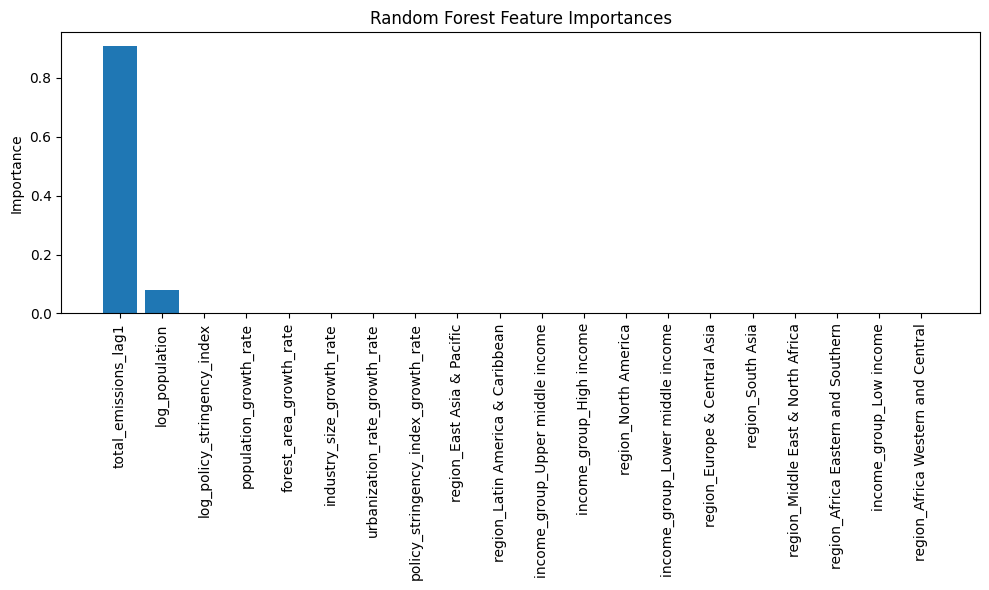

In [47]:
# 2. Train RandomForest on train split
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. Evaluate on test split
y_pred = rf.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred)
r2_test  = r2_score(y_test, y_pred)
print(f"Test MSE: {mse_test:.3f}, R2: {r2_test:.3f}")

# 4. Panel cross-validation with GroupKFold
gkf = GroupKFold(n_splits=5)
cv_mse, cv_r2 = [], []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf_cv = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_cv.fit(X_tr, y_tr)

    y_val_pred = rf_cv.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    r2_val  = r2_score(y_val, y_val_pred)

    cv_mse.append(mse_val)
    cv_r2.append(r2_val)
    print(f"Fold {fold+1} - MSE: {mse_val:.3f}, R2: {r2_val:.3f}")

print(f"CV avg MSE: {np.mean(cv_mse):.3f}, R2: {np.mean(cv_r2):.3f}")

# 5. Time-series cross-validation on the training set
#    (sequential splits to respect temporal ordering)
tscv = TimeSeriesSplit(n_splits=5)
ts_mse, ts_r2 = [], []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    rf_ts = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_ts.fit(X_tr, y_tr)

    y_val_pred = rf_ts.predict(X_val)
    mse_ts = mean_squared_error(y_val, y_val_pred)
    r2_ts  = r2_score(y_val, y_val_pred)

    ts_mse.append(mse_ts)
    ts_r2.append(r2_ts)
    print(f"Time-series CV Fold {fold+1} - MSE: {mse_ts:.3f}, R2: {r2_ts:.3f}")

print(f"Time-series CV avg MSE: {np.mean(ts_mse):.3f}, R2: {np.mean(ts_r2):.3f}")

# 6. Plot feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(feature_cols)), importances[indices], align='center')
plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in indices], rotation=90)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

